In [ ]:
"""
This file may have been modified by Bytedance Ltd. and/or its affiliates (“Bytedance's Modifications”).
All Bytedance's Modifications are Copyright (year) Bytedance Ltd. and/or its affiliates. 

Reference: https://github.com/facebookresearch/Mask2Former/blob/main/demo/demo.py
"""

import argparse

import time
import numpy as np

from detectron2.config import get_cfg
from detectron2.data.detection_utils import read_image
from detectron2.projects.deeplab import add_deeplab_config

from visual_language_navigation.fcclip.fcclip.config import add_maskformer2_config, add_fcclip_config


/home/user1/.local/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/user1/visual-language-navigation/vlmaps/fcclip/fcclip/modeling/pixel_decoder/msdeformattn.py:350: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


In [2]:


def setup_cfg(args):
    # load config from file and command-line arguments
    cfg = get_cfg()
    add_deeplab_config(cfg)
    add_maskformer2_config(cfg)
    add_fcclip_config(cfg)
    cfg.merge_from_file(args.config_file)
    cfg.merge_from_list(args.opts)
    cfg.freeze()
    return cfg

def get_parser():
    parser = argparse.ArgumentParser(description="fcclip demo for builtin configs")
    parser.add_argument(
        "--config-file",
        default="configs/coco/panoptic-segmentation/fcclip/fcclip_convnext_large_eval_ade20k.yaml",
        metavar="FILE",
        help="path to config file",
    )
    parser.add_argument("--webcam", action="store_true", help="Take inputs from webcam.")
    parser.add_argument("--video-input", help="Path to video file.")
    parser.add_argument(
        "--input",
        nargs="+",
        help="A list of space separated input images; "
        "or a single glob pattern such as 'directory/*.jpg'",
    )
    parser.add_argument(
        "--output",
        help="A file or directory to save output visualizations. "
        "If not given, will show output in an OpenCV window.",
    )

    parser.add_argument(
        "--confidence-threshold",
        type=float,
        default=0.5,
        help="Minimum score for instance predictions to be shown",
    )
    parser.add_argument(
        "--opts",
        help="Modify config options using the command-line 'KEY VALUE' pairs",
        default=[],
        nargs=argparse.REMAINDER,
    )
    return parser



In [ ]:

args = get_parser()

args.input = ["datasets/ADEChallengeData2016/images/training/ADE_train_00000001.jpg"]
args.opts = ["MODEL.WEIGHTS", "visual_language_navigation/fcclip/fcclip_cocopan.pth", "MODEL.DEVICE", "cuda"]
args.config_file = "/home/user1/ergo-maps/visual_language_navigation/fcclip/configs/coco/panoptic-segmentation/fcclip/fcclip_convnext_large_eval_ade20k.yaml"

cfg = setup_cfg(args)

In [7]:
from detectron2.modeling import build_model
from detectron2.checkpoint import DetectionCheckpointer
import detectron2.data.transforms as T


model = build_model(cfg)
model.eval()

checkpointer = DetectionCheckpointer(model)
checkpointer.load(cfg.MODEL.WEIGHTS)

aug = T.ResizeShortestEdge(
    [cfg.INPUT.MIN_SIZE_TEST, cfg.INPUT.MIN_SIZE_TEST], cfg.INPUT.MAX_SIZE_TEST
)

input_format = cfg.INPUT.FORMAT
assert input_format in ["RGB", "BGR"], input_format

TRAIN CLASS NAMES [['person', 'child', 'girl', 'boy', 'woman', 'man', 'people', 'children', 'girls', 'boys', 'women', 'men', 'lady', 'guy', 'ladies', 'guys', 'clothes'], ['bicycle', 'bicycles', 'bike', 'bikes'], ['car', 'cars'], ['motorcycle', 'motorcycles'], ['airplane', 'airplanes'], ['bus', 'buses'], ['train', 'trains', 'locomotive', 'locomotives', 'freight train'], ['truck', 'trucks'], ['boat', 'boats'], ['traffic light'], ['fire hydrant'], ['stop sign'], ['parking meter'], ['bench', 'benches'], ['bird', 'birds'], ['cat', 'cats', 'kitties', 'kitty'], ['dog', 'dogs', 'puppy', 'puppies'], ['horse', 'horses', 'foal'], ['sheep'], ['cow', 'cows', 'calf'], ['elephant', 'elephants'], ['bear', 'bears'], ['zebra', 'zebras'], ['giraffe', 'giraffes'], ['backpack', 'backpacks'], ['umbrella', 'umbrellas'], ['handbag', 'handbags'], ['tie'], ['suitcase', 'suitcases'], ['frisbee'], ['skis'], ['snowboard'], ['sports ball'], ['kite', 'kites'], ['baseball bat'], ['baseball glove'], ['skateboard'], ['

backbone.clip_model.ln_final.{bias, weight}
backbone.clip_model.token_embedding.weight
backbone.clip_model.transformer.resblocks.0.attn.out_proj.{bias, weight}
backbone.clip_model.transformer.resblocks.0.attn.{in_proj_bias, in_proj_weight}
backbone.clip_model.transformer.resblocks.0.ln_1.{bias, weight}
backbone.clip_model.transformer.resblocks.0.ln_2.{bias, weight}
backbone.clip_model.transformer.resblocks.0.mlp.c_fc.{bias, weight}
backbone.clip_model.transformer.resblocks.0.mlp.c_proj.{bias, weight}
backbone.clip_model.transformer.resblocks.1.attn.out_proj.{bias, weight}
backbone.clip_model.transformer.resblocks.1.attn.{in_proj_bias, in_proj_weight}
backbone.clip_model.transformer.resblocks.1.ln_1.{bias, weight}
backbone.clip_model.transformer.resblocks.1.ln_2.{bias, weight}
backbone.clip_model.transformer.resblocks.1.mlp.c_fc.{bias, weight}
backbone.clip_model.transformer.resblocks.1.mlp.c_proj.{bias, weight}
backbone.clip_model.transformer.resblocks.10.attn.out_proj.{bias, weight}
b

In [8]:
import torch

with torch.no_grad():  # https://github.com/sphinx-doc/sphinx/issues/4258
    # Apply pre-processing to image.

    original_image = read_image(args.input[0], format="BGR")

    if input_format == "RGB":
        # whether the model expects BGR inputs or RGB
        original_image = original_image[:, :, ::-1]
    height, width = original_image.shape[:2]
    image = aug.get_transform(original_image).apply_image(original_image)
    image = torch.as_tensor(image.astype("float32").transpose(2, 0, 1))
    image.to(cfg.MODEL.DEVICE)

    inputs = {"image": image, "height": height, "width": width}

    start_time = time.time()
    featured_image = model.get_image_embeddings([inputs])[0]
    print("Time:", time.time() - start_time)

Time: 0.7951023578643799


/home/user1/.local/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


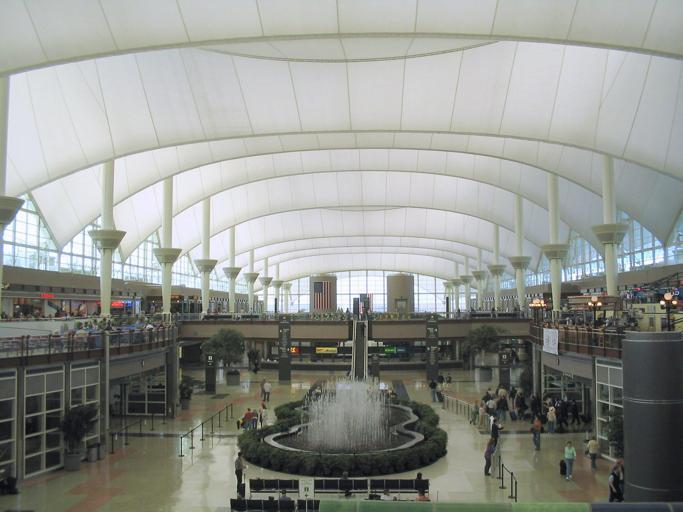

In [9]:
from PIL import Image

input_image = Image.open(args.input[0])
input_image

In [ ]:
features, indexed_image = featured_image

torch.Size([250, 1536])

In [ ]:
category_list = [["chair"], ["table"], ["floor"], ["lamp"], ["wall"], ["person"],["dog"], ["box"], ["ceiling"], ["tv"], ["laptop"], ["shelf"], ["robot"]]
# category_list = [["sofa"], ["table"], ["lamp"], ["plant"], ["wall"], ["floor"], ["ceiling"], ["laptop"], ["dog"], ["carpet"], ["android"], ["shelf"]]

# category_list = [["table"], ["shelf"], ["floor"], ["wall"], ["text"], ["writing"], ["curtains"], ["sign"], ["book"], ["painting"], ["tree"], ["mirror"], ["window"]]
# category_list = [["curtains"], ["text"], ["frame"], ["horse"], ["person"], ["man"], ["woman"], ["people"], ["window"], ["tree"], ["wall"], ["mirror"], ["sky"], ["grass"]]
# category_list = [["writing"], ["text"], ["words"], ["sign"], ["signboard"], ["book"], ["notes"], ["notice"]]
category_list = [["table"]]

with torch.no_grad():
    # max_indices = model.get_segmentation(category_list, featured_image)
    max_indices = model.query_segmentation(category_list, features.unsqueeze(0))

IndexError: too many indices for tensor of dimension 2

In [34]:
max_indices

(tensor([[2, 2, 2,  ..., 1, 1, 1],
         [1, 1, 2,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]], device='cuda:0'),
 tensor([[[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         ...,
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]]], device='cuda:0', dtype=torch.int8))

In [35]:
import matplotlib.pyplot as plt
import torch

colors = plt.cm.nipy_spectral(np.linspace(0, 1, len(category_list) + 2))

label_index_to_color_dict = {i: torch.tensor(colors[i]) for i in range(len(category_list) + 2)}

# Initialize open_seg_mask

open_seg_mask = torch.zeros(featured_image.shape[0], featured_image.shape[1], 4)

open_seg_mask = torch.stack([label_index_to_color_dict[idx.item()] for idx in max_indices.flatten()]).view(open_seg_mask.shape)


AttributeError: 'tuple' object has no attribute 'flatten'

In [ ]:

detected_categories = torch.unique(max_indices)
detected_categories

tensor([0, 1, 2], device='cuda:0')

['table', 'other', 'zero embedding']


/tmp/ipykernel_3952/776619815.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  found_categories_legend = ax.legend(handles=[plt.Rectangle((0,0),1,1, color=np.array(label_index_to_color_dict[int(i)]),


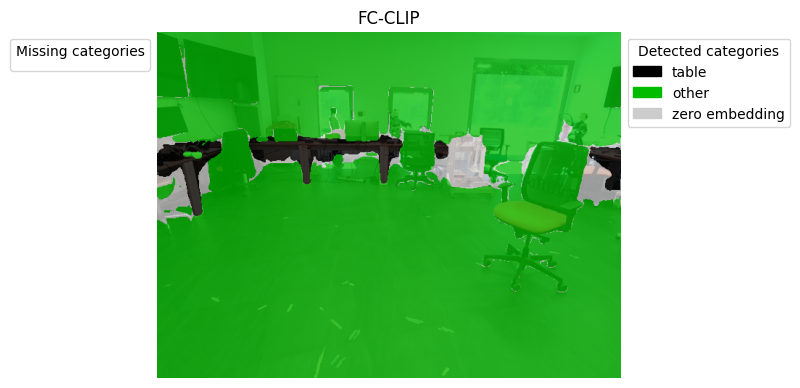

In [ ]:
fig, ax = plt.subplots()

plt.imshow(input_image)
plt.imshow(open_seg_mask, alpha=.75)

labels = [", ".join(w) for w in category_list]
labels.append("other")
labels.append("zero embedding")
print(labels)

found_categories_legend = ax.legend(handles=[plt.Rectangle((0,0),1,1, color=np.array(label_index_to_color_dict[int(i)]),                                                       
                                        # label=[w for wl in category_list for w in wl][int(i)]) for i in range(len(category_list)) if i in detected_categories],
                                        label=labels[int(i)]) for i in range(len(labels)) if i in detected_categories],
                                        title = "Detected categories",   
                                        loc='upper left', bbox_to_anchor=(1, 1),
                                        )

missing_categories_legend = plt.legend(handles=[plt.Rectangle((0,0),1,1, color=np.array(label_index_to_color_dict[int(i)]),
                                        # label=[w for wl in category_list for w in wl][int(i)]) for i in range(len(category_list)) if i not in detected_categories],
                                        label=labels[int(i)]) for i in range(len(category_list)) if i not in detected_categories],
                                        title= "Missing categories",
                                        loc='upper right', bbox_to_anchor=(0, 1),
                                        )

# Manually add the first legend back to the plot
fig.add_artist(found_categories_legend)

format = "svg"

plt.title("FC-CLIP")
plt.axis("off")
plt.tight_layout()

if len(category_list) == 1:
    plt.savefig(f'fc-clip_{category_list[0][0]}.{format}', format=format, bbox_inches='tight')
else:
    plt.savefig(f'fc-clip.{format}', format=format, bbox_inches='tight')

/tmp/ipykernel_3952/459455802.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  found_categories_legend = ax.legend(handles=[plt.Rectangle((0,0),1,1, color=np.array(label_index_to_color_dict[int(i)]),


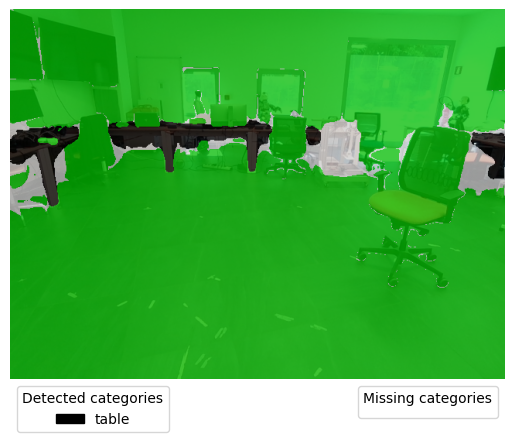

In [ ]:
fig, ax = plt.subplots()

plt.imshow(input_image)
plt.imshow(open_seg_mask, alpha=.75)
# found_categories_legend.remove()

found_categories_legend = ax.legend(handles=[plt.Rectangle((0,0),1,1, color=np.array(label_index_to_color_dict[int(i)]),                                                       
                                        label=[w for wl in category_list for w in wl][int(i)]) for i in range(len(category_list)) if i in detected_categories],
                                        title = "Detected categories",   
                                        loc='upper left', bbox_to_anchor=(0, 0),
                                        )

missing_categories_legend = plt.legend(handles=[plt.Rectangle((0,0),1,1, color=np.array(label_index_to_color_dict[int(i)]),
                                        label=[w for wl in category_list for w in wl][int(i)]) for i in range(len(category_list)) if i not in detected_categories],
                                        title= "Missing categories",
                                        loc='upper right', bbox_to_anchor=(1, 0),
                                        )

# Manually add the first legend back to the plot
fig.add_artist(found_categories_legend)

# plt.tight_layout()

plt.axis("off")

plt.show()

# plt.legend(handles=[plt.Rectangle((0,0),1,1, color=np.array(label_index_to_color_dict[int(i)]), label=[w for wl in word_list for w in wl][int(i)]) for i in range(len(embeddings))], loc='upper left', bbox_to_anchor=(1, 1))

